# OpenRouter Model Audit

Fetches all models available through your OpenRouter-compatible endpoint, shows a pricing table, then tests every **free** model and plots their response latency.

## Setup

In [1]:
%pip install -q pandas matplotlib requests


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import time
import requests
import dotenv
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

dotenv.load_dotenv("../.env", override=True)

OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL", "https://openrouter.ai/api/v1")
OPENAI_API_KEY  = os.environ.get("OPENAI_API_KEY")

assert OPENAI_API_KEY, "OPENAI_API_KEY is not set — check your .env file"

HEADERS = {
    "Authorization": f"Bearer {OPENAI_API_KEY}",
    "Content-Type":  "application/json",
}

print(f"Base URL : {OPENAI_BASE_URL}")
print(f"API key  : {OPENAI_API_KEY[:4]}...{OPENAI_API_KEY[-4:]}")

Base URL : https://openrouter.ai/api/v1
API key  : sk-o...aafb


## Fetch Available Models

Pull the full model catalogue from the `/models` endpoint. The base URL is taken from `OPENAI_BASE_URL` in your `.env`, which should point at OpenRouter (or a compatible proxy).

In [3]:
# OpenRouter always exposes /models at the canonical URL regardless of proxy setup
MODELS_URL = "https://openrouter.ai/api/v1/models"

resp = requests.get(MODELS_URL, headers=HEADERS, timeout=30)
resp.raise_for_status()

models_raw = resp.json().get("data", [])
print(f"Found {len(models_raw)} models")

Found 356 models


## Pricing Table

Prices converted to **USD per 1 million tokens**. Rows where both prompt and completion cost $0 are highlighted — those are the "free" models we will test.

In [4]:
def to_per_million(price_str) -> float:
    """Convert per-token price string to USD per 1M tokens."""
    try:
        return float(price_str or 0) * 1_000_000
    except (ValueError, TypeError):
        return 0.0


rows = []
for m in models_raw:
    pricing    = m.get("pricing", {})
    prompt_pm  = to_per_million(pricing.get("prompt",     0))
    compl_pm   = to_per_million(pricing.get("completion", 0))
    rows.append({
        "id":               m.get("id"),
        "name":             m.get("name", m.get("id")),
        "context_length":   m.get("context_length"),
        "prompt_$/1M":      prompt_pm,
        "completion_$/1M":  compl_pm,
        "is_free":          prompt_pm == 0.0 and compl_pm == 0.0,
    })

df = pd.DataFrame(rows).sort_values(
    ["is_free", "prompt_$/1M"], ascending=[False, True]
).reset_index(drop=True)

pd.set_option("display.max_rows", 300)

def highlight_free(row):
    color = "background-color: #d4edda" if row["is_free"] else ""
    return [color] * len(row)

(
    df[["name", "context_length", "prompt_$/1M", "completion_$/1M", "is_free"]]
    .style
    .apply(highlight_free, axis=1)
    .format({"prompt_$/1M": "${:.4f}", "completion_$/1M": "${:.4f}"})
    .set_caption(f"OpenRouter Models — Pricing ({len(df)} total, {df['is_free'].sum()} free)")
)

,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,Baidu Qianfan: CoBuddy (free),131072,$0.0000,$0.0000,True
1,Owl Alpha,1048756,$0.0000,$0.0000,True
2,NVIDIA: Nemotron 3 Nano Omni (free),256000,$0.0000,$0.0000,True
3,Poolside: Laguna XS.2 (free),131072,$0.0000,$0.0000,True
4,Poolside: Laguna M.1 (free),131072,$0.0000,$0.0000,True
5,DeepSeek: DeepSeek V4 Flash (free),1048576,$0.0000,$0.0000,True
6,Google: Gemma 4 26B A4B (free),262144,$0.0000,$0.0000,True
7,Google: Gemma 4 31B (free),262144,$0.0000,$0.0000,True
8,Arcee AI: Trinity Large Thinking (free),262144,$0.0000,$0.0000,True
9,Google: Lyria 3 Pro Preview,1048576,$0.0000,$0.0000,True


## Models by Provider

Count of total and free models per provider, with prompt price range.

In [5]:
df["provider"] = df["id"].str.split("/").str[0]

for provider, group in df.groupby("provider", sort=True):
    table = (
        group[["name", "context_length", "prompt_$/1M", "completion_$/1M", "is_free"]]
        .sort_values("prompt_$/1M")
        .reset_index(drop=True)
    )
    display(
        table.style
        .apply(highlight_free, axis=1)
        .format({"prompt_$/1M": "${:.4f}", "completion_$/1M": "${:.4f}"})
        .set_caption(f"{provider}  ({len(table)} models)")
    )

,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,AI21: Jamba Large 1.7,256000,$2.0000,$8.0000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,AI21: Jamba Large 1.7,256000,$2.0000,$8.0000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,AionLabs: Aion-1.0-Mini,131072,$0.7000,$1.4000,False
1,AionLabs: Aion-2.0,131072,$0.8000,$1.6000,False
2,AionLabs: Aion-RP 1.0 (8B),32768,$0.8000,$1.6000,False
3,AionLabs: Aion-1.0,131072,$4.0000,$8.0000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,AI21: Jamba Large 1.7,256000,$2.0000,$8.0000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,AionLabs: Aion-1.0-Mini,131072,$0.7000,$1.4000,False
1,AionLabs: Aion-2.0,131072,$0.8000,$1.6000,False
2,AionLabs: Aion-RP 1.0 (8B),32768,$0.8000,$1.6000,False
3,AionLabs: Aion-1.0,131072,$4.0000,$8.0000,False


...

,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,Z.ai: GLM 4.5 Air (free),131072,$0.0000,$0.0000,True
1,Z.ai: GLM 4.7 Flash,202752,$0.0600,$0.4000,False
2,Z.ai: GLM 4 32B,128000,$0.1000,$0.1000,False
3,Z.ai: GLM 4.5 Air,131072,$0.1300,$0.8500,False
4,Z.ai: GLM 4.6V,131072,$0.3000,$0.9000,False
5,Z.ai: GLM 4.7,202752,$0.4000,$1.7500,False
6,Z.ai: GLM 4.6,202752,$0.4300,$1.7400,False
7,Z.ai: GLM 5,202752,$0.6000,$1.9200,False
8,Z.ai: GLM 4.5V,65536,$0.6000,$1.8000,False
9,Z.ai: GLM 4.5,131072,$0.6000,$2.2000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,Anthropic Claude Haiku Latest,200000,$1.0000,$5.0000,False
1,Anthropic Claude Sonnet Latest,1000000,$3.0000,$15.0000,False
2,Anthropic: Claude Opus Latest,1000000,$5.0000,$25.0000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,Google Gemini Flash Latest,1048576,$0.5000,$3.0000,False
1,Google Gemini Pro Latest,1048576,$2.0000,$12.0000,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,MoonshotAI Kimi Latest,262144,$0.7300,$3.4900,False


,name,context_length,prompt_$/1M,completion_$/1M,is_free
0,OpenAI GPT Mini Latest,400000,$0.7500,$4.5000,False
1,OpenAI GPT Latest,1050000,$5.0000,$30.0000,False


## Free Models

List every model with $0 prompt + completion cost.

In [6]:
free_df = df[df["is_free"]].copy().reset_index(drop=True)
print(f"{len(free_df)} free models found:\n")
for mid in free_df["id"]:
    print(f"  - {mid}")

28 free models found:

  - baidu/cobuddy:free
  - openrouter/owl-alpha
  - nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
  - poolside/laguna-xs.2:free
  - poolside/laguna-m.1:free
  - deepseek/deepseek-v4-flash:free
  - google/gemma-4-26b-a4b-it:free
  - google/gemma-4-31b-it:free
  - arcee-ai/trinity-large-thinking:free
  - google/lyria-3-pro-preview
  - google/lyria-3-clip-preview
  - nvidia/nemotron-3-super-120b-a12b:free
  - minimax/minimax-m2.5:free
  - openrouter/free
  - liquid/lfm-2.5-1.2b-thinking:free
  - liquid/lfm-2.5-1.2b-instruct:free
  - nvidia/nemotron-3-nano-30b-a3b:free
  - nvidia/nemotron-nano-12b-v2-vl:free
  - qwen/qwen3-next-80b-a3b-instruct:free
  - nvidia/nemotron-nano-9b-v2:free
  - openai/gpt-oss-120b:free
  - openai/gpt-oss-20b:free
  - z-ai/glm-4.5-air:free
  - qwen/qwen3-coder:free
  - cognitivecomputations/dolphin-mistral-24b-venice-edition:free
  - meta-llama/llama-3.3-70b-instruct:free
  - meta-llama/llama-3.2-3b-instruct:free
  - nousresearch/herme

## Test Free Model Availability & Latency

Sends a minimal single-word prompt to each free model concurrently and records whether it responds successfully and how long it takes.

> **Note**: Some free models are slow or rate-limited; each request has a 45-second timeout.

In [7]:
CHAT_URL    = f"{OPENAI_BASE_URL.rstrip('/')}/chat/completions"
TIMEOUT_S   = 5    # per model
MAX_WORKERS = 10     # concurrent requests

def test_model(model_id: str) -> dict:
    """Call a model with a tiny prompt and record latency + outcome."""
    payload = {
        "model":    model_id,
        "messages": [{"role": "user", "content": "Reply with exactly one word: OK"}],
        "max_tokens": 10,
    }
    t0 = time.perf_counter()
    try:
        r = requests.post(CHAT_URL, json=payload, headers=HEADERS, timeout=TIMEOUT_S)
        latency = time.perf_counter() - t0
        if r.status_code == 200:
            content = (
                r.json()
                 .get("choices", [{}])[0]
                 .get("message", {})
                 .get("content", "")
                 .strip()
            )
            return {"model": model_id, "status": "ok",    "latency_s": round(latency, 2),
                    "response": content, "error": None}
        else:
            return {"model": model_id, "status": "error", "latency_s": round(latency, 2),
                    "response": None, "error": f"HTTP {r.status_code}: {r.text[:150]}"}
    except Exception as exc:
        return {"model": model_id, "status": "error",
                "latency_s": round(time.perf_counter() - t0, 2),
                "response": None, "error": str(exc)[:150]}

In [8]:
free_model_ids = free_df["id"].tolist()
results = []

print(f"Testing {len(free_model_ids)} free models (max {MAX_WORKERS} concurrent, {TIMEOUT_S}s timeout each)…\n")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futures = {pool.submit(test_model, mid): mid for mid in free_model_ids}
    for fut in as_completed(futures):
        r = fut.result()
        icon = "✓" if r["status"] == "ok" else "✗"
        detail = r["error"] if r["error"] else f'replied: "{r["response"]}"'
        print(f"  {icon}  {r['model']:<55s}  {r['latency_s']:.2f}s  {detail}")
        results.append(r)

results_df = pd.DataFrame(results).sort_values("latency_s").reset_index(drop=True)

Testing 28 free models (max 10 concurrent, 5s timeout each)…

  ✗  google/gemma-4-31b-it:free                               0.36s  HTTP 429: {"error":{"message":"Provider returned error","code":429,"metadata":{"raw":"google/gemma-4-31b-it:free is temporarily rate-limited upstream. Please re
  ✗  google/gemma-4-26b-a4b-it:free                           0.41s  HTTP 429: {"error":{"message":"Provider returned error","code":429,"metadata":{"raw":"google/gemma-4-26b-a4b-it:free is temporarily rate-limited upstream. Pleas
  ✗  poolside/laguna-xs.2:free                                0.50s  'NoneType' object has no attribute 'strip'
  ✗  poolside/laguna-m.1:free                                 0.63s  'NoneType' object has no attribute 'strip'
  ✗  arcee-ai/trinity-large-thinking:free                     0.62s  'NoneType' object has no attribute 'strip'
  ✗  liquid/lfm-2.5-1.2b-thinking:free                        0.51s  'NoneType' object has no attribute 'strip'
  ✗  google/lyria-3-pro-previe

## Results Summary

In [9]:
ok_df   = results_df[results_df["status"] == "ok"].reset_index(drop=True)
fail_df = results_df[results_df["status"] != "ok"].reset_index(drop=True)

print(f"Working : {len(ok_df)}")
print(f"Failed  : {len(fail_df)}")
print(f"Total   : {len(results_df)}\n")

print("=== WORKING MODELS ===")
display(ok_df[["model", "latency_s", "response"]])

if not fail_df.empty:
    print("\n=== FAILED MODELS ===")
    display(fail_df[["model", "latency_s", "error"]])

Working : 7
Failed  : 21
Total   : 28

=== WORKING MODELS ===


Working : 7
Failed  : 21
Total   : 28

=== WORKING MODELS ===


,model,latency_s,response
0,liquid/lfm-2.5-1.2b-instruct:free,0.59,OK
1,openai/gpt-oss-120b:free,1.17,OK
2,openai/gpt-oss-20b:free,1.76,OK
3,nvidia/nemotron-nano-12b-v2-vl:free,3.45,OK
4,nvidia/nemotron-3-super-120b-a12b:free,3.52,"The user asks: ""Reply with exactly one word"
5,openrouter/free,6.34,OK
6,deepseek/deepseek-v4-flash:free,65.04,OK



=== FAILED MODELS ===


,model,latency_s,error
0,qwen/qwen3-coder:free,0.28,"HTTP 429: {""error"":{""message"":""Provider return..."
1,cognitivecomputations/dolphin-mistral-24b-veni...,0.29,"HTTP 429: {""error"":{""message"":""Provider return..."
2,nousresearch/hermes-3-llama-3.1-405b:free,0.32,"HTTP 429: {""error"":{""message"":""Provider return..."
3,meta-llama/llama-3.3-70b-instruct:free,0.33,"HTTP 429: {""error"":{""message"":""Provider return..."
4,google/gemma-4-31b-it:free,0.36,"HTTP 429: {""error"":{""message"":""Provider return..."
5,google/gemma-4-26b-a4b-it:free,0.41,"HTTP 429: {""error"":{""message"":""Provider return..."
6,nvidia/nemotron-3-nano-30b-a3b:free,0.43,'NoneType' object has no attribute 'strip'
7,poolside/laguna-xs.2:free,0.50,'NoneType' object has no attribute 'strip'
8,liquid/lfm-2.5-1.2b-thinking:free,0.51,'NoneType' object has no attribute 'strip'
9,arcee-ai/trinity-large-thinking:free,0.62,'NoneType' object has no attribute 'strip'


## Latency Plot — Working Free Models

Horizontal bar chart sorted fastest → slowest. Saved to `images/free_model_latency.png`.

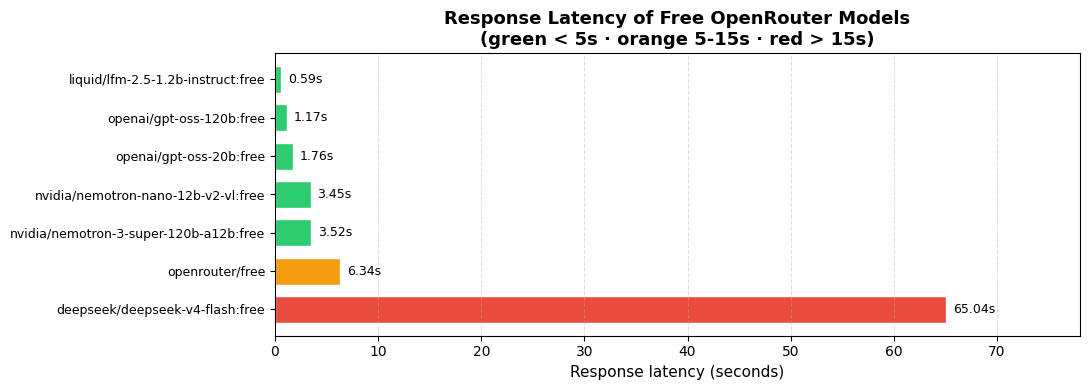

Saved → images/free_model_latency.png


In [11]:
if ok_df.empty:
    print("No working free models to plot.")
else:
    plot_df = ok_df.sort_values("latency_s", ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4, len(plot_df) * 0.45)))
    colors = ["#2ecc71" if s < 5 else "#f39c12" if s < 15 else "#e74c3c"
              for s in plot_df["latency_s"]]
    bars = ax.barh(plot_df["model"], plot_df["latency_s"],
                   color=colors, edgecolor="white", height=0.7)

    ax.bar_label(bars, fmt="%.2fs", padding=5, fontsize=9)
    ax.set_xlabel("Response latency (seconds)", fontsize=11)
    ax.set_title("Response Latency of Free OpenRouter Models\n"
                 "(green < 5s · orange 5-15s · red > 15s)",
                 fontsize=13, fontweight="bold")
    ax.invert_yaxis()   # fastest at top
    ax.set_xlim(0, plot_df["latency_s"].max() * 1.20)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.tick_params(axis="y", labelsize=9)

    plt.tight_layout()
    plt.savefig("../images/free_model_latency.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → images/free_model_latency.png")

In [13]:
print("=== WORKING FREE MODELS ===")
for _, row in ok_df[["model","latency_s"]].iterrows():
    print(f"  {row['model']}  {row['latency_s']}s")

print("\n=== CHEAP PAID (openai/google/anthropic) ===")
paid = df[~df["is_free"] & df["provider"].isin(["openai","google","anthropic"])].sort_values("prompt_$/1M")
for _, row in paid[["id","prompt_$/1M","completion_$/1M"]].head(15).iterrows():
    print(f"  {row['id']}  prompt=${row['prompt_$/1M']:.4f}  compl=${row['completion_$/1M']:.4f}")

=== WORKING FREE MODELS ===
  liquid/lfm-2.5-1.2b-instruct:free  0.59s
  openai/gpt-oss-120b:free  1.17s
  openai/gpt-oss-20b:free  1.76s
  nvidia/nemotron-nano-12b-v2-vl:free  3.45s
  nvidia/nemotron-3-super-120b-a12b:free  3.52s
  openrouter/free  6.34s
  deepseek/deepseek-v4-flash:free  65.04s

=== CHEAP PAID (openai/google/anthropic) ===
  openai/gpt-oss-20b  prompt=$0.0300  compl=$0.1400
  openai/gpt-oss-120b  prompt=$0.0390  compl=$0.1800
  google/gemma-3-4b-it  prompt=$0.0400  compl=$0.0800
  google/gemma-3-12b-it  prompt=$0.0400  compl=$0.1300
  openai/gpt-5-nano  prompt=$0.0500  compl=$0.4000
  google/gemma-4-26b-a4b-it  prompt=$0.0600  compl=$0.3300
  google/gemma-3n-e4b-it  prompt=$0.0600  compl=$0.1200
  openai/gpt-oss-safeguard-20b  prompt=$0.0750  compl=$0.3000
  google/gemini-2.0-flash-lite-001  prompt=$0.0750  compl=$0.3000
  google/gemma-3-27b-it  prompt=$0.0800  compl=$0.1600
  google/gemini-2.0-flash-001  prompt=$0.1000  compl=$0.4000
  openai/gpt-4.1-nano  prompt=$0